<a href="https://colab.research.google.com/github/nikolay909694/StatPrac/blob/main/DZ5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}


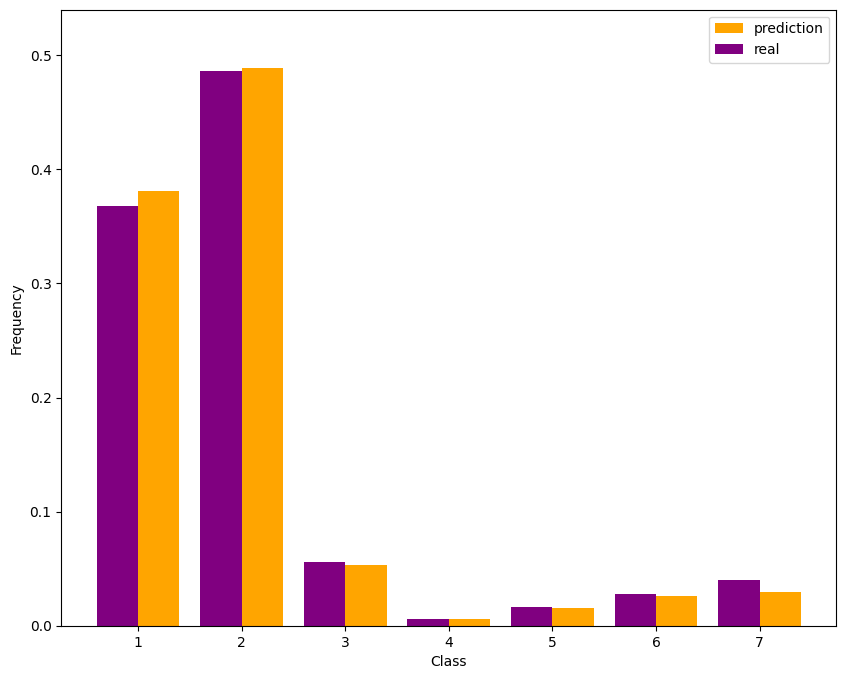

Test accuracy: 0.7845


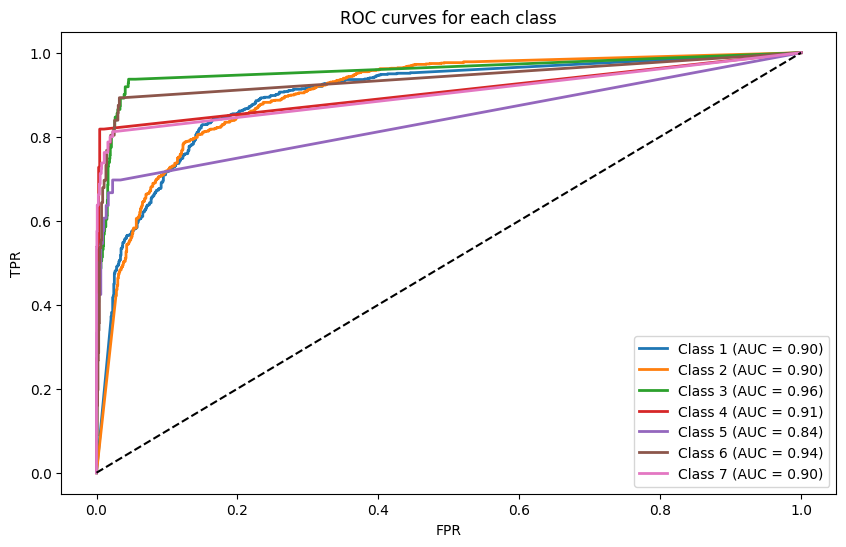

Mean AUC-ROC: 0.9063452430548241


In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

all_data = pd.read_csv("forest_dataset.csv", header=None)

labels = all_data[all_data.columns[-1]].values
feature_matrix = all_data[all_data.columns[:-1]].values

mask = labels <= 7
labels = labels[mask]
feature_matrix = feature_matrix[mask]


X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix, labels, test_size=0.2, random_state=42
)

clf = KNeighborsClassifier()

params = {
    "n_neighbors": range(1, 11),
    "metric": ["manhattan", "euclidean"],
    "weights": ["uniform", "distance"]
}

clf_grid = GridSearchCV(clf, params, cv=5, scoring="accuracy", n_jobs=-1)
clf_grid.fit(X_train, y_train)
print(clf_grid.best_params_)

optimal_clf = KNeighborsClassifier(**clf_grid.best_params_)
optimal_clf.fit(X_train, y_train)

pred_prob = optimal_clf.predict_proba(X_test)

unique, freq = np.unique(y_test, return_counts=True)
freq = list(map(lambda x: x / len(y_test), freq))
pred_freq = pred_prob.mean(axis=0)

plt.figure(figsize=(10, 8))
plt.bar(range(1, 8), pred_freq, width=0.4, align="edge", label="prediction", color='orange')
plt.bar(range(1, 8), freq, width=-0.4, align="edge", label="real", color='purple')
plt.ylim(0, 0.54)
plt.ylabel('Frequency')
plt.xlabel('Class')
plt.legend()
plt.show()

y_pred = optimal_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", acc)

y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4, 5, 6, 7])
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(7):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 6))
for i in range(7):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"Class {i+1} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC curves for each class")
plt.legend()
plt.show()

print("Mean AUC-ROC:", np.mean(list(roc_auc.values())))

Качество модели на тестовой выборке составило 0.7845.
Логистическая регрессия на этом датасете обычно показывает результат около 0.70–0.73.
Таким образом, kNN оказался лучше, что объясняется наличием нелинейных зависимостей в данных.


Преимущества метода k ближайших соседей:


Простота реализации и интерпретации
Обучение происходит быстро (фактически запоминание данных)
Способен учитывать сложные нелинейные зависимости


Недостатки метода:

Необходимость хранения всей обучающей выборки
Высокая вычислительная сложность при классификации нового объекта
Чувствительность к выбору метрики, количества соседей и масштабированию признаков
